In [10]:
import pandas as pd
#df = pd.read_csv("data\application_train.csv")
df = pd.read_csv("../data/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [7]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [9]:
df.shape

(307511, 122)

In [11]:
df['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

imbalance dataset:target is the column 0: repaid

1: customer defaulter
value_counts(): counts how many times each value appears
normalize= ture means converts counts into percentage
we are doing this to check if our dataset is imbalanced or not
becaue predicting defaulters is hard and important model can cheat by always predicting 0

In [12]:
#check missing values
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(10)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
dtype: float64

isnull() → finds missing values
.mean() → converts to percentage
.sort_values() → highest missing first

In [ ]:
#removes highly missing columns
cols_to_drop = missing[missing > 0.5].index

df = df.drop(columns=cols_to_drop)

df.shape

(307511, 81)

In [15]:
# handle remaining missing values
#find all numeric vcolumns
#fills missing values withe median

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum().sum()

C:\Users\ANJALI\AppData\Local\Temp\ipykernel_14456\811801548.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\ANJALI\AppData\Local\Temp\ipykernel_14456\811801548.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

np.int64(1616066)

###1616066 missing values still remin
so numeric columns are done, but categorical colums still have missing values
fill all categorical columns missing woth most frequent value mode 

In [16]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum().sum()

C:\Users\ANJALI\AppData\Local\Temp\ipykernel_14456\3061436468.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
C:\Users\ANJALI\AppData\Local\Temp\ipykernel_14456\3061436468.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when do

np.int64(1616066)

In [17]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum().sum()

np.int64(1372628)

In [18]:
df = df.fillna(df.median(numeric_only=True))

df = df.fillna(0)

df.isnull().sum().sum()

np.int64(0)

In [19]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object', 'string']).columns

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
#feature engineering
df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / (df['AMT_CREDIT'] + 1)

df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

df['EMPLOYED_BIRTH_RATIO'] = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,INCOME_CREDIT_RATIO,ANNUITY_INCOME_RATIO,EMPLOYED_BIRTH_RATIO
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0.0,0.0,0.0,0.0,0.0,1.0,0.498034,0.121977,0.067336
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.208735,0.132216,0.070866
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.499996,0.099999,0.011814
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0.0,0.0,0.0,0.0,0.0,1.0,0.431746,0.219898,0.159914
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.236842,0.179961,0.152426


In [22]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X.shape, y.shape

((307511, 83), (307511,))

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((246008, 83), (61503, 83))

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\ANJALI\OneDrive\Desktop\Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
from sklearn.metrics import roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_pred_proba)

0.6260556977417493

In [26]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19876, number of negative: 226132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080794 -> initscore=-2.431606
[LightGBM] [Info] Start training from score -2.431606


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [27]:
from sklearn.metrics import roc_auc_score

y_pred_lgb = lgb_model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, y_pred_lgb)

0.7516666175632967

In [28]:
import shap

explainer = shap.Explainer(lgb_model, X_train)

shap_values = explainer(X_test[:100])

c:\Users\ANJALI\OneDrive\Desktop\Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


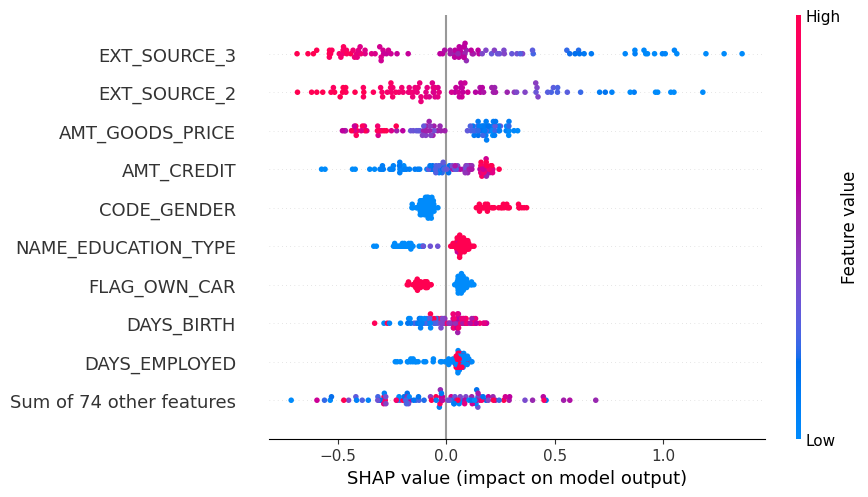

In [29]:
shap.plots.beeswarm(shap_values)

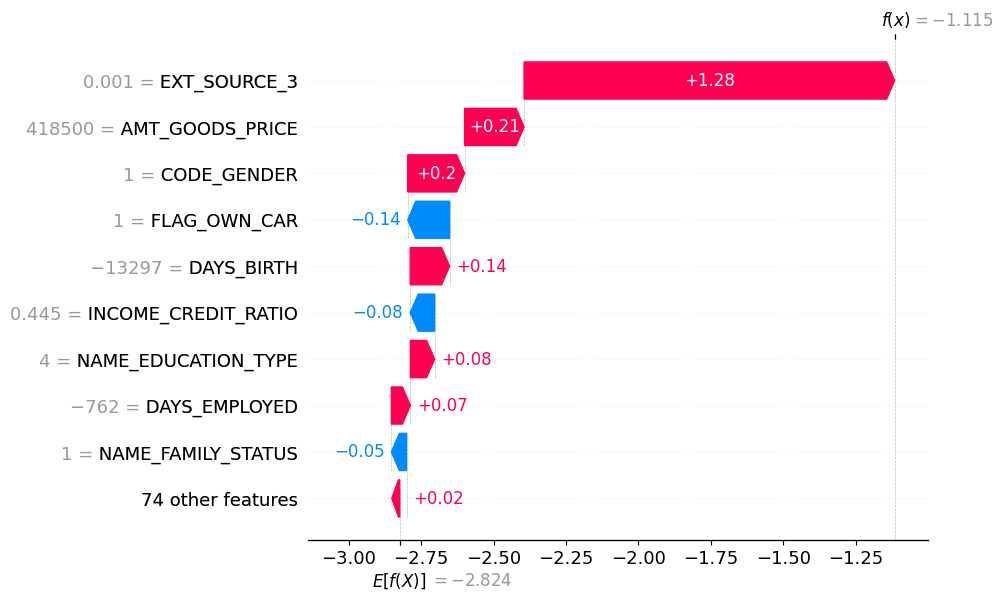

In [30]:
shap.plots.waterfall(shap_values[0])

In [32]:
import joblib

joblib.dump(lgb_model, "models/lgb_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'models/lgb_model.pkl'

In [33]:
import joblib

joblib.dump(lgb_model, "../models/lgb_model.pkl")

['../models/lgb_model.pkl']

In [34]:
X_test.iloc[0].values.tolist()

[384575.0,
 0.0,
 1.0,
 1.0,
 0.0,
 2.0,
 207000.0,
 465457.5,
 52641.0,
 418500.0,
 6.0,
 1.0,
 4.0,
 1.0,
 1.0,
 0.00963,
 -13297.0,
 -762.0,
 -637.0,
 -4307.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 14.0,
 4.0,
 2.0,
 2.0,
 4.0,
 11.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 5.0,
 0.6048943383603742,
 0.0005272652387098,
 0.9816,
 0.1667,
 0.9816,
 0.1667,
 0.9816,
 0.1667,
 0.0688,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -2.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.4447227840935336,
 0.2543031193086024,
 0.057310469314079425]

In [35]:
import requests

url = "http://127.0.0.1:5000/predict"

data = {
    "features": [384575.0,0.0,1.0,1.0,0.0,2.0,207000.0,465457.5,52641.0,418500.0,6.0,1.0,4.0,1.0,1.0,0.00963,-13297.0,-762.0,-637.0,-4307.0,1.0,1.0,0.0,1.0,0.0,0.0,14.0,4.0,2.0,2.0,4.0,11.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,0.6048943383603742,0.0005272652387098,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.4447227840935336,0.2543031193086024,0.057310469314079425]
}

response = requests.post(url, json=data)

response.json()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [36]:
print(response.status_code)
print(response.text)

500
<!doctype html>
<html lang=en>
  <head>
    <title>ValueError: X has 84 features, but LGBMClassifier is expecting 83 features as input.
 // Werkzeug Debugger</title>
    <link rel="stylesheet" href="?__debugger__=yes&amp;cmd=resource&amp;f=style.css">
    <link rel="shortcut icon"
        href="?__debugger__=yes&amp;cmd=resource&amp;f=console.png">
    <script src="?__debugger__=yes&amp;cmd=resource&amp;f=debugger.js"></script>
    <script>
      var CONSOLE_MODE = false,
          EVALEX = true,
          EVALEX_TRUSTED = false,
          SECRET = "fmpJkG4rT084cBDtamR7";
    </script>
  </head>
  <body style="background-color: #fff">
    <div class="debugger">
<h1>ValueError</h1>
<div class="detail">
  <p class="errormsg">ValueError: X has 84 features, but LGBMClassifier is expecting 83 features as input.
</p>
</div>
<h2 class="traceback">Traceback <em>(most recent call last)</em></h2>
<div class="traceback">
  <h3></h3>
  <ul><li><div class="frame" id="frame-2536544993664">
  <h4

In [37]:
X_test.iloc[0].drop('SK_ID_CURR').values.tolist()

[0.0,
 1.0,
 1.0,
 0.0,
 2.0,
 207000.0,
 465457.5,
 52641.0,
 418500.0,
 6.0,
 1.0,
 4.0,
 1.0,
 1.0,
 0.00963,
 -13297.0,
 -762.0,
 -637.0,
 -4307.0,
 1.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 14.0,
 4.0,
 2.0,
 2.0,
 4.0,
 11.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 5.0,
 0.6048943383603742,
 0.0005272652387098,
 0.9816,
 0.1667,
 0.9816,
 0.1667,
 0.9816,
 0.1667,
 0.0688,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -2.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.4447227840935336,
 0.2543031193086024,
 0.057310469314079425]

In [38]:
import requests

url = "http://127.0.0.1:5000/predict"

data = {
    "features": [0.0,1.0,1.0,0.0,2.0,207000.0,465457.5,52641.0,418500.0,6.0,1.0,4.0,1.0,1.0,0.00963,-13297.0,-762.0,-637.0,-4307.0,1.0,1.0,0.0,1.0,0.0,0.0,14.0,4.0,2.0,2.0,4.0,11.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,0.6048943383603742,0.0005272652387098,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,0.0,0.0,0.0,0.0,0.0,-2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.4447227840935336,0.2543031193086024,0.057310469314079425]
}

response = requests.post(url, json=data)

response.json()

{'prediction': 0, 'probability': 0.4979239770210565}